# Semana 4 — XGBoost + Clases Desbalanceadas + Threshold Tuning

Esta semana añadimos XGBoost al stack de modelos, exploramos tres estrategias para manejar el desbalance de clases, y aprendemos a ajustar el threshold de clasificación según el costo real del negocio — no dejarlo en 0.5 por defecto.

---

In [24]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

X_train      = joblib.load('X_train.pkl')
X_test       = joblib.load('X_test.pkl')
y_train      = joblib.load('y_train.pkl')
y_test       = joblib.load('y_test.pkl')
preprocessor = joblib.load('preprocessor.pkl')
pipe_rf      = joblib.load('pipeline_rf.pkl')
y_proba_rf   = np.load('y_proba_rf.npy')

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Churn rate: {y_train.mean():.1%}')

Train: 5,634  |  Test: 1,409
Churn rate: 26.6%


In [25]:
# Actualizar preprocessor para imputar NaN en TotalCharges
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# Crear preprocessor con imputación
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SkPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Ajustar en train
preprocessor.fit(X_train)

# Guardar
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor actualizado con imputación y guardado.")

Preprocessor actualizado con imputación y guardado.


In [26]:
# Recrear pipeline_rf con los nuevos datos
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_rf.fit(X_train, y_train)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

# Guardar
joblib.dump(pipe_rf, 'pipeline_rf.pkl')
np.save('y_proba_rf.npy', y_proba_rf)
print("Pipeline RF recreado y guardado.")

Pipeline RF recreado y guardado.


---
## 1. Tres estrategias para clases desbalanceadas

Comparamos `scale_pos_weight` (XGBoost nativo), `class_weight='balanced'` (sklearn) y SMOTE (oversampling sintético), para entender cuándo usar cada una.

In [27]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Clase 0 (No churn): {neg:,}')
print(f'Clase 1 (Churn):    {pos:,}')
print(f'scale_pos_weight:   {scale_pos_weight:.2f}')
print('Interpretación: cada ejemplo de churn vale 2.8x más al calcular el error')

Clase 0 (No churn): 4,138
Clase 1 (Churn):    1,496
scale_pos_weight:   2.77
Interpretación: cada ejemplo de churn vale 2.8x más al calcular el error


In [28]:
# Estrategia 1: scale_pos_weight (nativo de XGBoost)
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))
])
pipe_xgb.fit(X_train, y_train)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
print(f'XGBoost (scale_pos_weight)  AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}')

XGBoost (scale_pos_weight)  AUC: 0.8565


In [29]:
# Estrategia 2: SMOTE (oversampling sintético)
# SMOTE crea ejemplos sintéticos de la clase minoritaria interpolando entre vecinos reales
# Requiere imblearn.Pipeline (no sklearn.Pipeline) para aplicarse solo en train

pipe_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))
])
pipe_smote.fit(X_train, y_train)
y_proba_smote = pipe_smote.predict_proba(X_test)[:, 1]
print(f'XGBoost + SMOTE             AUC: {roc_auc_score(y_test, y_proba_smote):.4f}')

XGBoost + SMOTE             AUC: 0.8566


In [30]:
# Comparativa de las tres estrategias
estrategias = [
    ('Random Forest (balanced)',   y_proba_rf,    pipe_rf.predict(X_test)),
    ('XGBoost (scale_pos_weight)', y_proba_xgb,   pipe_xgb.predict(X_test)),
    ('XGBoost + SMOTE',            y_proba_smote, pipe_smote.predict(X_test)),
]

rows = []
for name, proba, pred in estrategias:
    rows.append({
        'Estrategia':  name,
        'AUC-ROC':     round(roc_auc_score(y_test, proba), 4),
        'PR-AUC':      round(average_precision_score(y_test, proba), 4),
        'F1':          round(f1_score(y_test, pred), 4),
        'Recall':      round(recall_score(y_test, pred), 4),
        'Precision':   round(precision_score(y_test, pred), 4),
    })

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))
print()
print('Cuándo usar cada estrategia:')
print('  scale_pos_weight → más rápido, sin modificar los datos, primera opción')
print('  SMOTE            → útil cuando el desbalance es muy extremo (>10:1)')
print('  class_weight     → equivalente a scale_pos_weight en modelos sklearn')

                Estrategia  AUC-ROC  PR-AUC     F1  Recall  Precision
  Random Forest (balanced)   0.8641  0.6986 0.6628  0.7694     0.5822
XGBoost (scale_pos_weight)   0.8565  0.6880 0.6501  0.8043     0.5455
           XGBoost + SMOTE   0.8566  0.6831 0.6466  0.6622     0.6317

Cuándo usar cada estrategia:
  scale_pos_weight → más rápido, sin modificar los datos, primera opción
  SMOTE            → útil cuando el desbalance es muy extremo (>10:1)
  class_weight     → equivalente a scale_pos_weight en modelos sklearn


---
## 2. Threshold Tuning

El threshold por defecto es 0.5: si la probabilidad predicha supera 0.5, el modelo dice "churn". Ese valor es arbitrario. El threshold óptimo depende del costo relativo entre un falso negativo y un falso positivo en el negocio.

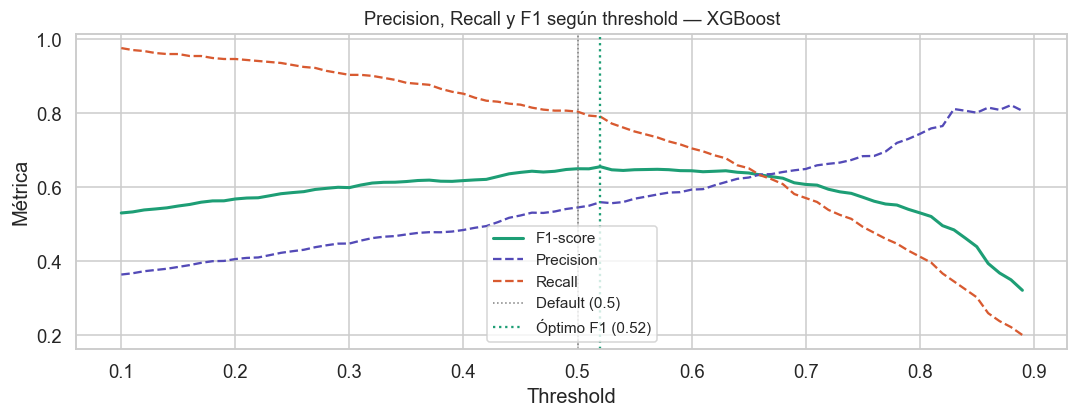

Threshold default (0.50):  F1=0.6501
Threshold óptimo  (0.52):  F1=0.6556


In [31]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, precision_scores, recall_scores = [], [], []

for t in thresholds:
    pred_t = (y_proba_xgb >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))
    precision_scores.append(precision_score(y_test, pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, pred_t, zero_division=0))

best_t_f1 = thresholds[np.argmax(f1_scores)]
best_f1   = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores,        color='#1D9E75', linewidth=2, label='F1-score')
ax.plot(thresholds, precision_scores, color='#534AB7', linewidth=1.5, linestyle='--', label='Precision')
ax.plot(thresholds, recall_scores,    color='#D85A30', linewidth=1.5, linestyle='--', label='Recall')
ax.axvline(0.5,       color='gray',    linewidth=1, linestyle=':',  label='Default (0.5)')
ax.axvline(best_t_f1, color='#1D9E75', linewidth=1.5, linestyle=':', label=f'Óptimo F1 ({best_t_f1:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title('Precision, Recall y F1 según threshold — XGBoost', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_12_threshold_tuning.png', bbox_inches='tight')
plt.show()

print(f'Threshold default (0.50):  F1={f1_score(y_test, (y_proba_xgb>=0.50).astype(int)):.4f}')
print(f'Threshold óptimo  ({best_t_f1:.2f}):  F1={best_f1:.4f}')

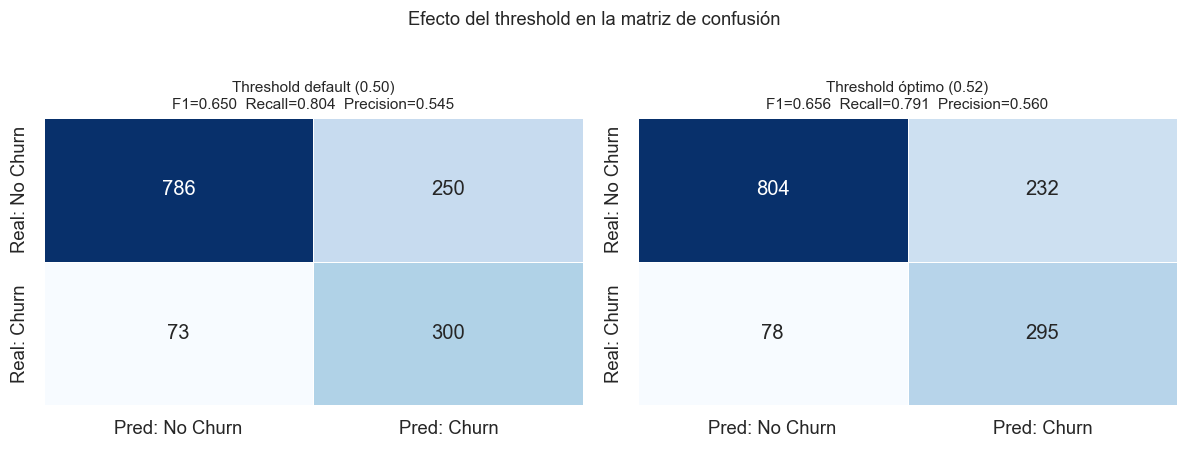

In [32]:
# Comparar el efecto del threshold en la matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, t, label in [
    (axes[0], 0.50,       'Threshold default (0.50)'),
    (axes[1], best_t_f1,  f'Threshold óptimo ({best_t_f1:.2f})')
]:
    pred_t = (y_proba_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                linewidths=0.5, cbar=False,
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'])
    f1_t = f1_score(y_test, pred_t)
    rec_t = recall_score(y_test, pred_t)
    pre_t = precision_score(y_test, pred_t)
    ax.set_title(f'{label}\nF1={f1_t:.3f}  Recall={rec_t:.3f}  Precision={pre_t:.3f}', fontsize=10)

plt.suptitle('Efecto del threshold en la matriz de confusión', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plot_13_confusion_threshold.png', bbox_inches='tight')
plt.show()

---
## 3. Threshold según costo de negocio

En un caso real el threshold no se elige por F1 sino por el costo económico de cada tipo de error. Aquí simulamos ese análisis.

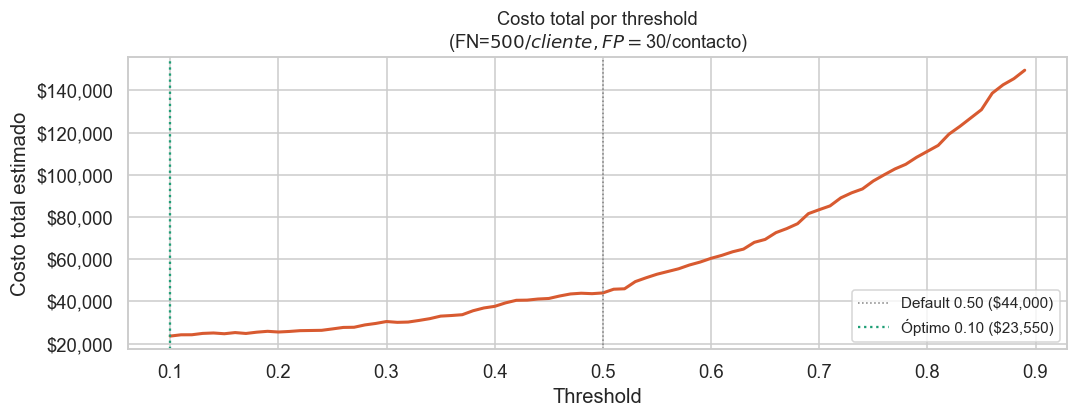

Threshold default 0.50:  costo estimado $44,000
Threshold óptimo  0.10:  costo estimado $23,550
Reducción de costo:      46.5%


In [33]:
COSTO_FN = 500   # perder un cliente que se iba: valor de vida estimado
COSTO_FP = 30    # contactar a un cliente que no iba a irse: costo de campaña

costos = []
for t in thresholds:
    pred_t = (y_proba_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    fn = cm[1, 0]
    fp = cm[0, 1]
    costos.append(fn * COSTO_FN + fp * COSTO_FP)

best_t_costo = thresholds[np.argmin(costos)]
costo_default = costos[np.argmin(np.abs(thresholds - 0.50))]
costo_optimo  = min(costos)
ahorro_pct    = (costo_default - costo_optimo) / costo_default

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, costos, color='#D85A30', linewidth=2)
ax.axvline(0.50,           color='gray',    linewidth=1,   linestyle=':', label=f'Default 0.50 (${costo_default:,.0f})')
ax.axvline(best_t_costo,   color='#1D9E75', linewidth=1.5, linestyle=':', label=f'Óptimo {best_t_costo:.2f} (${costo_optimo:,.0f})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('Threshold')
ax.set_ylabel('Costo total estimado')
ax.set_title(f'Costo total por threshold\n(FN=${COSTO_FN}/cliente, FP=${COSTO_FP}/contacto)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_14_costo_threshold.png', bbox_inches='tight')
plt.show()

print(f'Threshold default 0.50:  costo estimado ${costo_default:,.0f}')
print(f'Threshold óptimo  {best_t_costo:.2f}:  costo estimado ${costo_optimo:,.0f}')
print(f'Reducción de costo:      {ahorro_pct:.1%}')

---
## 4. Tabla final con el modelo y threshold elegidos

In [34]:
y_pred_final = (y_proba_xgb >= best_t_costo).astype(int)

print('=== MODELO FINAL: XGBoost con threshold óptimo por costo ===')
print(f'Threshold elegido: {best_t_costo:.2f}')
print(f'AUC-ROC:    {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'F1-score:   {f1_score(y_test, y_pred_final):.4f}')
print(f'Precision:  {precision_score(y_test, y_pred_final):.4f}')
print(f'Recall:     {recall_score(y_test, y_pred_final):.4f}')

=== MODELO FINAL: XGBoost con threshold óptimo por costo ===
Threshold elegido: 0.10
AUC-ROC:    0.8565
F1-score:   0.5306
Precision:  0.3644
Recall:     0.9759


---
## 5. Guardar modelo y threshold

In [35]:
import json

joblib.dump(pipe_xgb, 'pipeline_xgb.pkl')
np.save('y_proba_xgb.npy', y_proba_xgb)

with open('model_config.json', 'w') as f:
    json.dump({
        'modelo_final':    'XGBoost',
        'threshold':       round(float(best_t_costo), 2),
        'costo_fn':        COSTO_FN,
        'costo_fp':        COSTO_FP,
        'auc_roc':         round(roc_auc_score(y_test, y_proba_xgb), 4),
        'f1_threshold':    round(f1_score(y_test, y_pred_final), 4),
        'recall':          round(recall_score(y_test, y_pred_final), 4),
        'precision':       round(precision_score(y_test, y_pred_final), 4)
    }, f, indent=2)

print('Guardado: pipeline_xgb.pkl, y_proba_xgb.npy, model_config.json')

Guardado: pipeline_xgb.pkl, y_proba_xgb.npy, model_config.json
